# Supervised Learning for Predicting TREFMXAV_U in Manchester (2050–2080)

## Research Question
How well can supervised learning models predict daily maximum near-surface air temperature (`TREFMXAV_U`) in Manchester using climate predictors from the CESM Large Ensemble dataset for the period from 2050 onward?

## Goal
Compare the predictive performance of five supervised learning models:

- XGBoost Regressor (XGB)
- LightGBM Regressor (LGBM)
- Random Forest Regressor (RF)
- Support Vector Regressor (SVR)
- PCA + Support Vector Regressor (SVR_PCA)

## Notes
- Target location: Manchester
- Data source: CESM-LENS NetCDF ensemble files
- Target variable: `TREFMXAV_U`
- Observed test period: from 2050-01-01 to the last available date in the uploaded files
- Extended forecast period: from the last available date to 2080-12-31 using climatological predictor extension

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
# =========================
# Basic configuration
# =========================

FILES = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc",
]

# Manchester coordinates
MAN_LAT = 53.4808
MAN_LON = -2.2426

# Convert lon to 0-360 if dataset uses that convention
if MAN_LON < 0:
    MAN_LON = MAN_LON % 360

TARGET = "TREFMXAV_U"

# Use the real variables present in the uploaded NetCDF files
PREFERRED_PREDICTORS = ["FLNS", "FSNS", "PRECT", "PRSN", "QBOT", "TREFHT", "UBOT", "VBOT"]
OPTIONAL_PREDICTORS = ["PSL", "RHREFHT"]

TRAIN_END = "2049-12-31"
TEST_START = "2050-01-01"
FORECAST_END = "2080-12-31"

RANDOM_STATE = 42

print("Configured files:")
for f in FILES:
    print(" -", f)

Configured files:
 - 003_2006_2080_352_360.nc
 - 004_2006_2080_352_360.nc
 - 005_2006_2080_352_360.nc
 - 006_2006_2080_352_360.nc
 - 007_2006_2080_352_360.nc
 - 008_2006_2080_352_360.nc


In [3]:
# =========================
# Helper functions
# =========================

def get_nearest_idx(lat_array, lon_array, target_lat, target_lon):
    lat_idx = np.abs(lat_array - target_lat).argmin()
    lon_idx = np.abs(lon_array - target_lon).argmin()
    return lat_idx, lon_idx

def build_dates_from_time(time_values, units):
    units = units.decode() if isinstance(units, bytes) else str(units)
    if "since" not in units:
        raise ValueError(f"Unexpected time units: {units}")

    base_date_str = units.split("since")[1].strip().split()[0]
    base_date = pd.Timestamp(base_date_str)

    # These files behave like 1-based day counts
    dates = base_date + pd.to_timedelta(np.asarray(time_values) - 1, unit="D")
    return pd.to_datetime(dates)

def add_time_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["DOY"] = df["Date"].dt.dayofyear
    df["sin_doy"] = np.sin(2 * np.pi * df["DOY"] / 365)
    df["cos_doy"] = np.cos(2 * np.pi * df["DOY"] / 365)
    return df

def detect_predictors(file_path):
    with h5py.File(file_path, "r") as f:
        available = list(f.keys())

    predictors = [v for v in PREFERRED_PREDICTORS if v in available]
    optional_found = [v for v in OPTIONAL_PREDICTORS if v in available]
    predictors += optional_found

    if TARGET not in available:
        raise KeyError(f"Target '{TARGET}' not found. Available variables: {available}")

    if len(predictors) == 0:
        raise KeyError(f"No valid predictors found. Available variables: {available}")

    print("Available variables in file:", available)
    print("Using predictors:", predictors)
    return predictors

PREDICTORS = detect_predictors(FILES[0])

def load_member_data(file_path):
    with h5py.File(file_path, "r") as f:
        available = list(f.keys())
        missing = [v for v in PREDICTORS + [TARGET] if v not in available]
        if missing:
            raise KeyError(f"Missing variables in {file_path}: {missing}. Available: {available}")

        lat = f["lat"][:]
        lon = f["lon"][:]

        lat_idx, lon_idx = get_nearest_idx(lat, lon, MAN_LAT, MAN_LON)

        data = {}
        for var in PREDICTORS + [TARGET]:
            arr = f[var][:, lat_idx, lon_idx].astype(float)
            arr[arr > 1e30] = np.nan
            data[var] = arr

        df = pd.DataFrame(data)

        # Convert temperatures from Kelvin to Celsius when applicable
        for temp_var in ["TREFHT", TARGET]:
            if temp_var in df.columns:
                df[temp_var] = df[temp_var] - 273.15

        time_values = f["time"][:]
        time_units = f["time"].attrs.get("units", "days since 2006-01-01")
        df["Date"] = build_dates_from_time(time_values, time_units)

    df = add_time_features(df)
    return df

def extend_member_to_2080_end(df_member):
    df_member = df_member.copy().sort_values("Date").reset_index(drop=True)

    last_date = df_member["Date"].max()
    target_end = pd.Timestamp(FORECAST_END)

    if last_date >= target_end:
        return df_member

    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), target_end, freq="D")
    future_df = pd.DataFrame({"Date": future_dates})
    future_df = add_time_features(future_df)

    clim = df_member.groupby("DOY")[PREDICTORS].mean().reset_index()
    future_df = future_df.merge(clim, on="DOY", how="left")

    for col in PREDICTORS:
        future_df[col] = future_df[col].fillna(df_member[col].mean())

    future_df[TARGET] = np.nan
    if "Member" in df_member.columns:
        future_df["Member"] = df_member["Member"].iloc[0]

    full_cols = list(df_member.columns)
    for c in full_cols:
        if c not in future_df.columns:
            future_df[c] = np.nan
    future_df = future_df[full_cols]

    return pd.concat([df_member, future_df], ignore_index=True)

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

def plot_predictions(dates, y_true, y_pred, model_name, max_points=1000):
    if len(dates) > max_points:
        idx = np.linspace(0, len(dates) - 1, max_points).astype(int)
        dates_plot = dates.iloc[idx]
        y_true_plot = y_true.iloc[idx] if isinstance(y_true, pd.Series) else y_true[idx]
        y_pred_plot = y_pred[idx]
    else:
        dates_plot = dates
        y_true_plot = y_true
        y_pred_plot = y_pred

    plt.figure(figsize=(14, 5))
    plt.plot(dates_plot, y_true_plot, label="Observed", linewidth=1)
    plt.plot(dates_plot, y_pred_plot, label="Predicted", linewidth=1)
    plt.title(f"{model_name}: Observed vs Predicted {TARGET} in Manchester")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_future_only(dates, y_pred, model_name):
    plt.figure(figsize=(12, 4))
    plt.plot(dates, y_pred, linewidth=1.5)
    plt.title(f"{model_name}: Forecast Extension to {FORECAST_END}")
    plt.xlabel("Date")
    plt.ylabel("Predicted Temperature (°C)")
    plt.tight_layout()
    plt.show()

Available variables in file: ['TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'TREFHT', 'UBOT', 'VBOT', 'lat', 'lon', 'time']
Using predictors: ['FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'TREFHT', 'UBOT', 'VBOT']


In [4]:
# =========================
# Load all ensemble members
# =========================

dfs = []
for file in FILES:
    print(f"Loading {file} ...")
    df_member = load_member_data(file)
    df_member["Member"] = os.path.basename(file).split("_")[0]
    df_member = extend_member_to_2080_end(df_member)
    dfs.append(df_member)

df_all = pd.concat(dfs, ignore_index=True)

print("\nCombined dataset shape:", df_all.shape)
print("Date range:", df_all["Date"].min(), "to", df_all["Date"].max())
print(df_all.tail())

Loading 003_2006_2080_352_360.nc ...
Loading 004_2006_2080_352_360.nc ...
Loading 005_2006_2080_352_360.nc ...
Loading 006_2006_2080_352_360.nc ...
Loading 007_2006_2080_352_360.nc ...
Loading 008_2006_2080_352_360.nc ...

Combined dataset shape: (164364, 15)
Date range: 2006-01-01 00:00:00 to 2080-12-31 00:00:00
             FLNS       FSNS         PRECT          PRSN      QBOT    TREFHT  \
164359  31.419817  17.137770  4.330959e-08  5.068232e-10  0.005090  6.536885   
164360  32.791173  17.415330  4.204114e-08  3.362732e-10  0.005119  6.715878   
164361  35.014099  19.048491  3.482879e-08  5.354229e-10  0.004959  6.217434   
164362  33.797787  18.825779  3.635989e-08  2.213857e-10  0.004995  6.488883   
164363  30.715377  17.948567  4.472662e-08  8.747174e-10  0.004936  5.870075   

            UBOT      VBOT  TREFMXAV_U       Date  Year  DOY       sin_doy  \
164359  2.239798  3.033732         NaN 2080-12-27  2080  362 -5.161967e-02   
164360  2.481917  2.667870         NaN 2080-12-2

In [5]:
# =========================
# Train-test split
# =========================

FEATURES = PREDICTORS + ["sin_doy", "cos_doy"]

df_train = df_all[df_all["Date"] <= TRAIN_END].copy()
df_test_all = df_all[df_all["Date"] >= TEST_START].copy()
df_test_obs = df_test_all[df_test_all[TARGET].notna()].copy()
df_test_future = df_test_all[df_test_all[TARGET].isna()].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]

X_test_obs = df_test_obs[FEATURES]
y_test_obs = df_test_obs[TARGET]
test_dates_obs = df_test_obs["Date"]

X_test_future = df_test_future[FEATURES]
test_dates_future = df_test_future["Date"]

print("Train shape       :", X_train.shape, y_train.shape)
print("Observed test     :", X_test_obs.shape, y_test_obs.shape)
print("Extended future   :", X_test_future.shape)
print("Observed test end :", test_dates_obs.max())
print("Forecast end      :", test_dates_future.max() if len(test_dates_future) > 0 else "No extension needed")

Train shape       : (96426, 10) (96426,)
Observed test     : (67818, 10) (67818,)
Extended future   : (120, 10)
Observed test end : 2080-12-11 00:00:00
Forecast end      : 2080-12-31 00:00:00


In [6]:
results = []
predictions_obs = {}
predictions_future = {}

  Model      RMSE       MAE        R2
0   XGB  0.686778  0.507231  0.983854


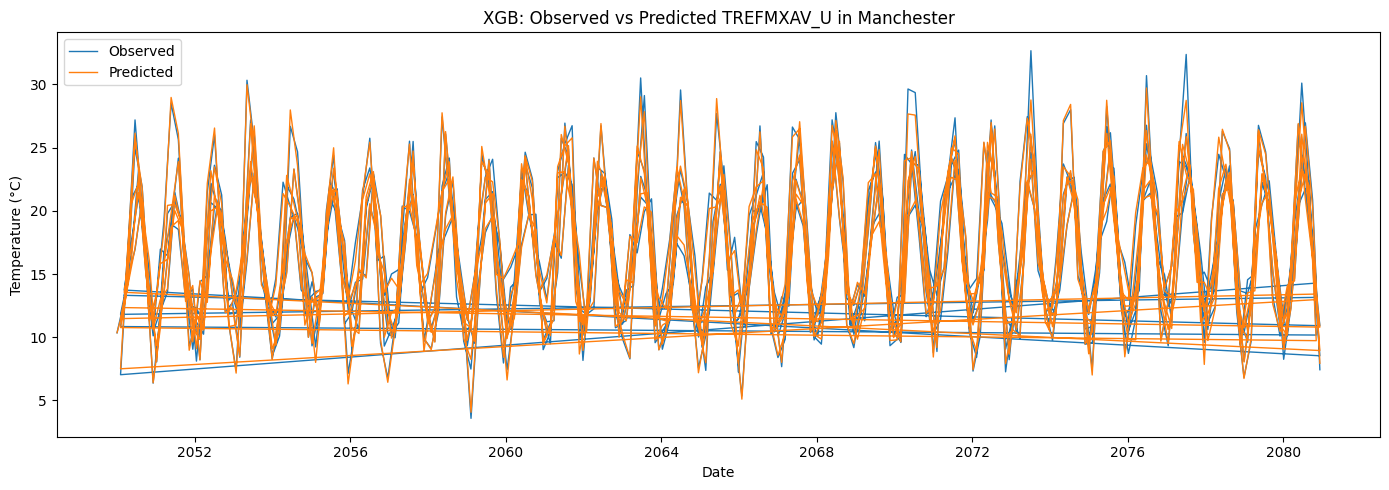

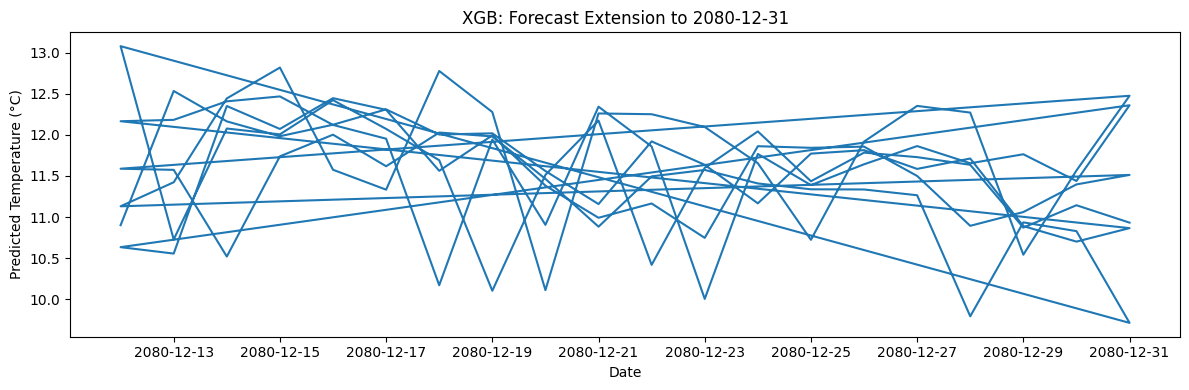

In [7]:
# =========================
# Model 1: XGB
# =========================

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred_obs = xgb_model.predict(X_test_obs)

predictions_obs["XGB"] = xgb_pred_obs
results.append(evaluate_model("XGB", y_test_obs, xgb_pred_obs))

print(pd.DataFrame([results[-1]]))
plot_predictions(test_dates_obs, y_test_obs, xgb_pred_obs, "XGB")

if len(X_test_future) > 0:
    xgb_pred_future = xgb_model.predict(X_test_future)
    predictions_future["XGB"] = xgb_pred_future
    plot_future_only(test_dates_future, xgb_pred_future, "XGB")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 96426, number of used features: 10
[LightGBM] [Info] Start training from score 15.061918
  Model      RMSE       MAE        R2
0  LGBM  0.688883  0.510151  0.983755


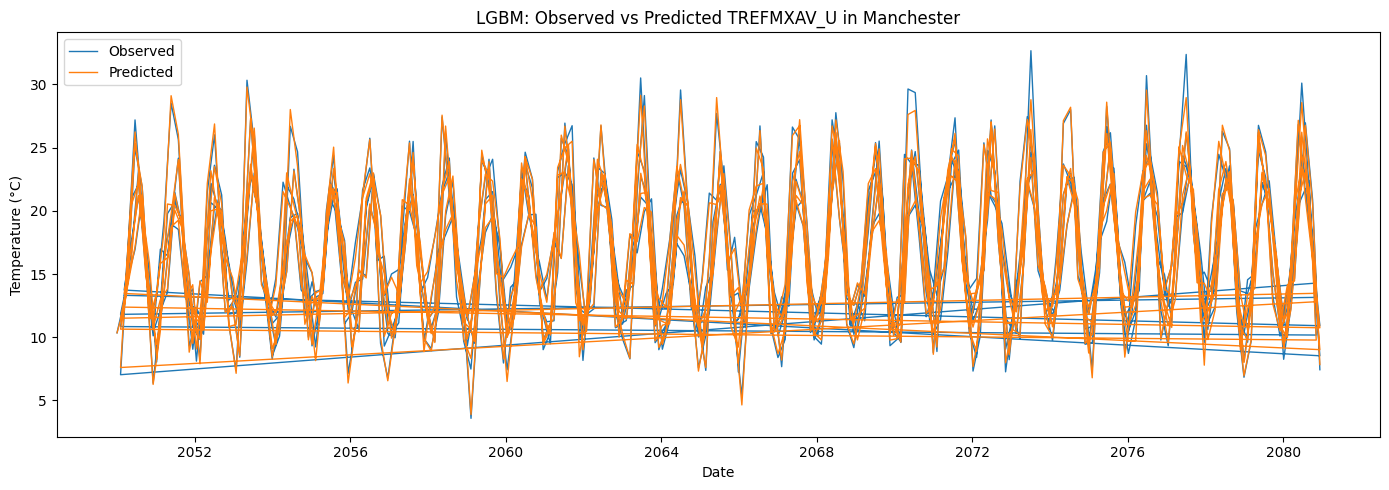

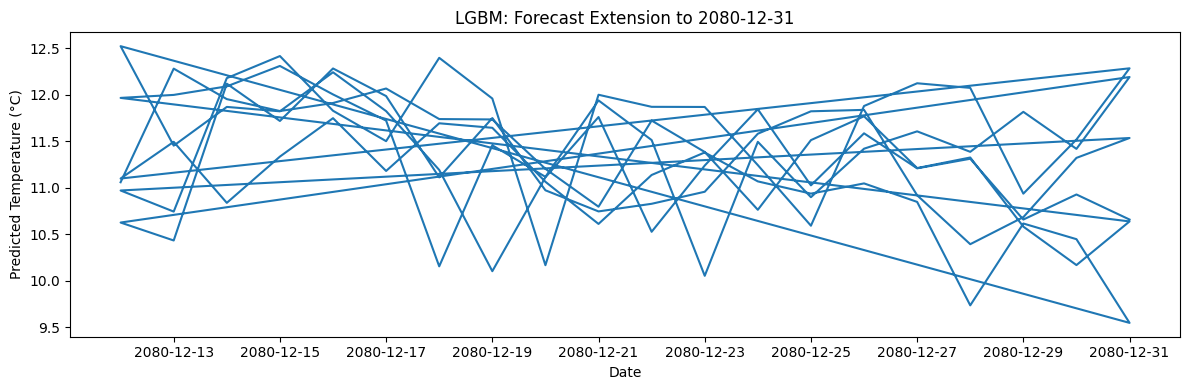

In [8]:
# =========================
# Model 2: LGBM
# =========================

lgbm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    ))
])

lgbm_model.fit(X_train, y_train)
lgbm_pred_obs = lgbm_model.predict(X_test_obs)

predictions_obs["LGBM"] = lgbm_pred_obs
results.append(evaluate_model("LGBM", y_test_obs, lgbm_pred_obs))

print(pd.DataFrame([results[-1]]))
plot_predictions(test_dates_obs, y_test_obs, lgbm_pred_obs, "LGBM")

if len(X_test_future) > 0:
    lgbm_pred_future = lgbm_model.predict(X_test_future)
    predictions_future["LGBM"] = lgbm_pred_future
    plot_future_only(test_dates_future, lgbm_pred_future, "LGBM")

  Model      RMSE       MAE        R2
0    RF  0.701269  0.529178  0.983166


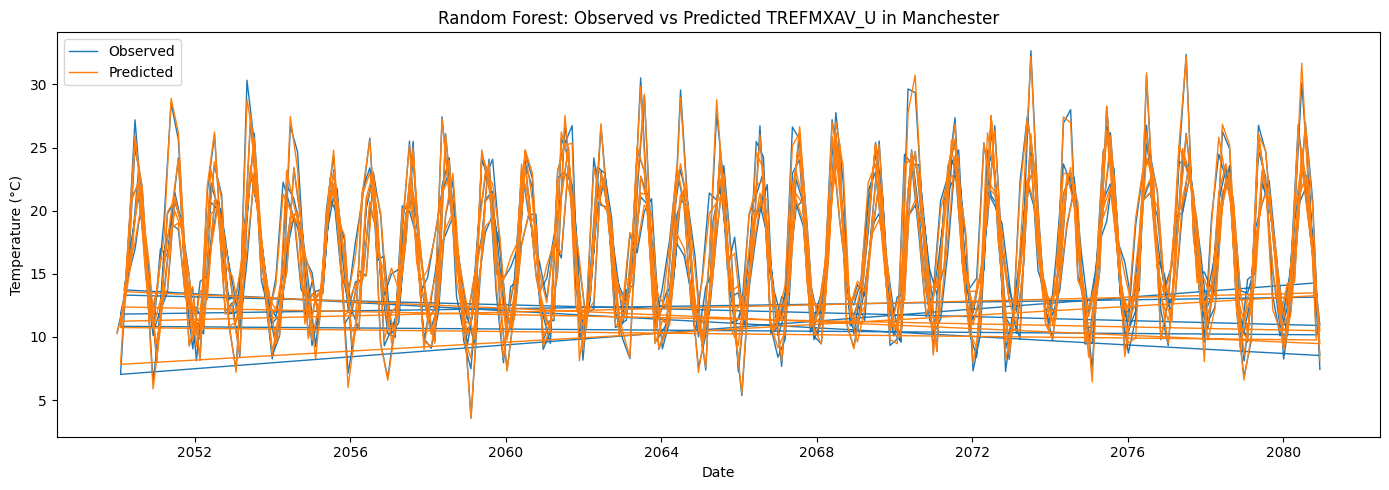

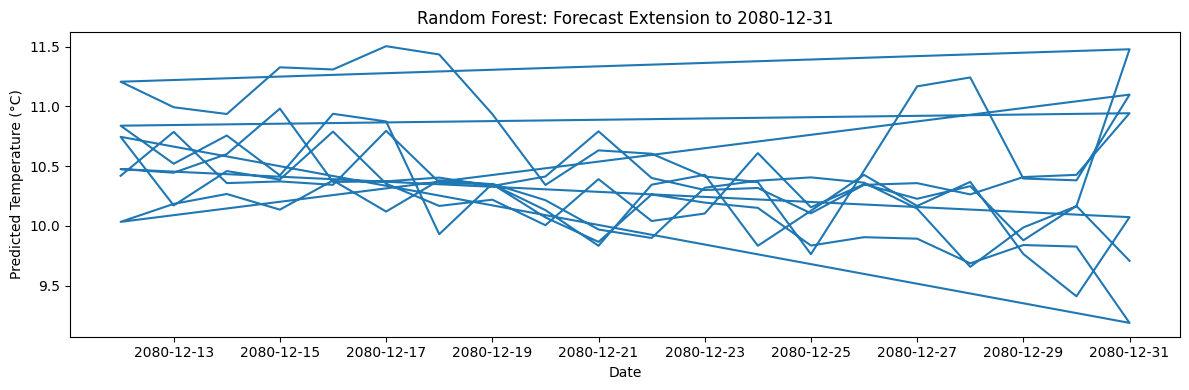

In [9]:
# =========================
# Model 3: Random Forest
# =========================

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred_obs = rf_model.predict(X_test_obs)

predictions_obs["RF"] = rf_pred_obs
results.append(evaluate_model("RF", y_test_obs, rf_pred_obs))

print(pd.DataFrame([results[-1]]))
plot_predictions(test_dates_obs, y_test_obs, rf_pred_obs, "Random Forest")

if len(X_test_future) > 0:
    rf_pred_future = rf_model.predict(X_test_future)
    predictions_future["RF"] = rf_pred_future
    plot_future_only(test_dates_future, rf_pred_future, "Random Forest")

SVR trained on 30000 sampled rows
  Model      RMSE       MAE        R2
0   SVR  0.659767  0.481275  0.985099


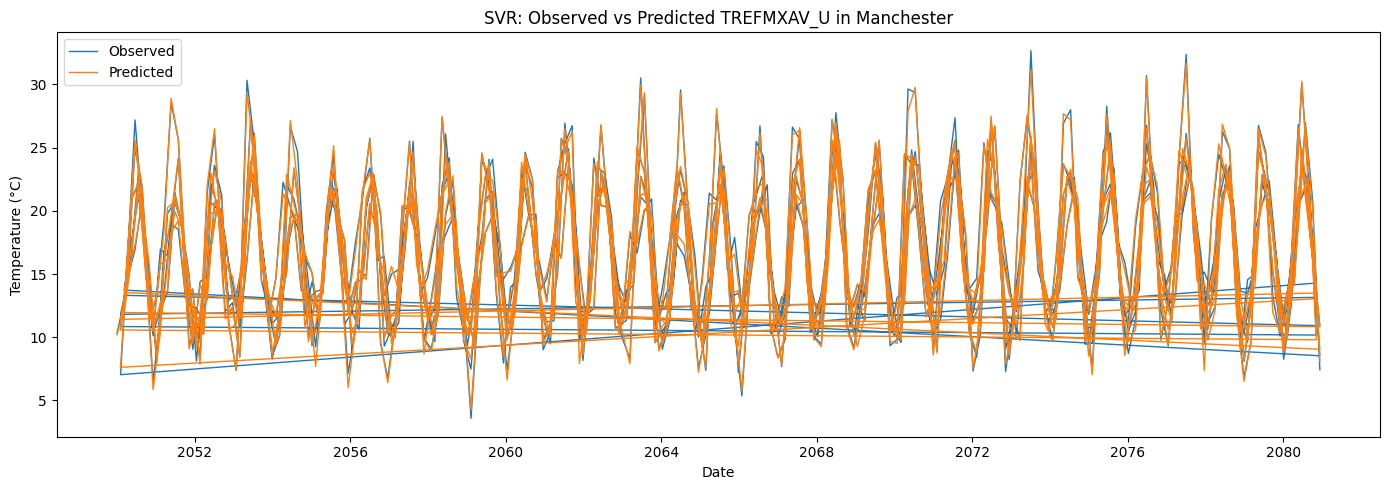

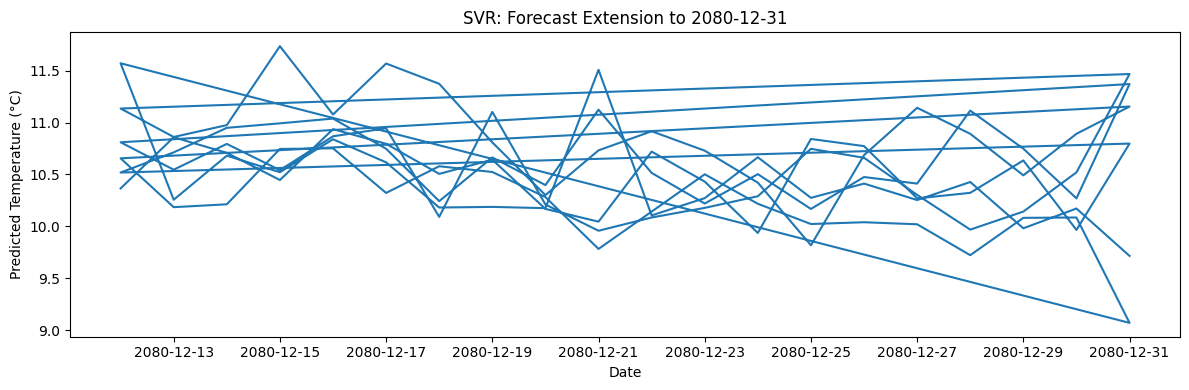

In [10]:
# =========================
# Model 4: SVR
# =========================

svr_sample_n = min(30000, len(X_train))
X_train_svr = X_train.sample(n=svr_sample_n, random_state=RANDOM_STATE)
y_train_svr = y_train.loc[X_train_svr.index]

svr_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1,
        gamma="scale"
    ))
])

svr_model.fit(X_train_svr, y_train_svr)
svr_pred_obs = svr_model.predict(X_test_obs)

predictions_obs["SVR"] = svr_pred_obs
results.append(evaluate_model("SVR", y_test_obs, svr_pred_obs))

print(f"SVR trained on {len(X_train_svr)} sampled rows")
print(pd.DataFrame([results[-1]]))
plot_predictions(test_dates_obs, y_test_obs, svr_pred_obs, "SVR")

if len(X_test_future) > 0:
    svr_pred_future = svr_model.predict(X_test_future)
    predictions_future["SVR"] = svr_pred_future
    plot_future_only(test_dates_future, svr_pred_future, "SVR")

SVR_PCA trained on 30000 sampled rows
     Model      RMSE       MAE        R2
0  SVR_PCA  0.907336  0.655446  0.971818


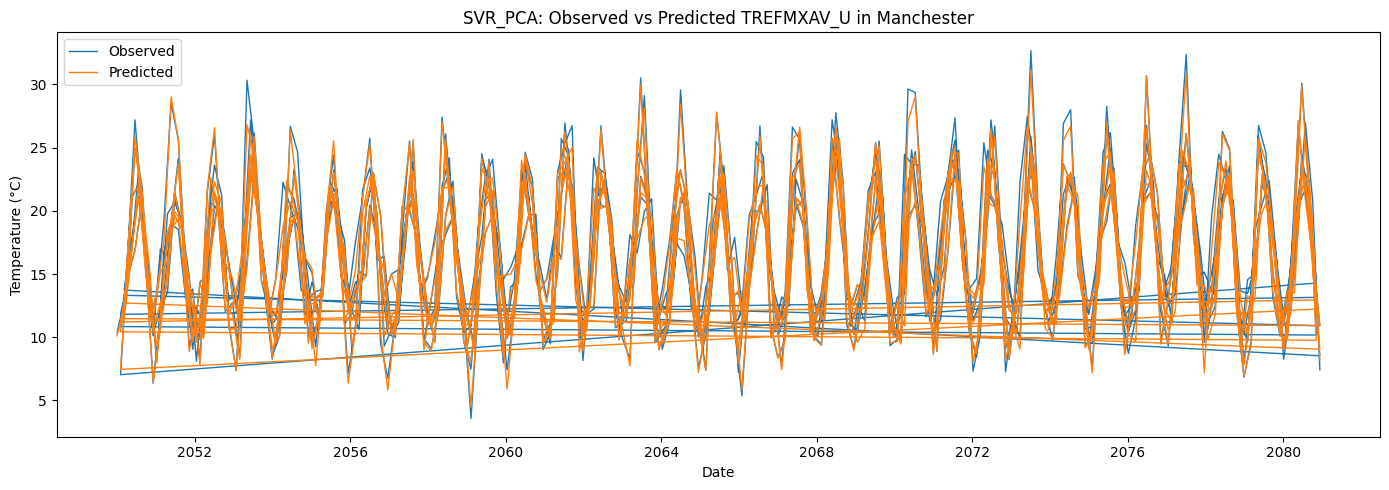

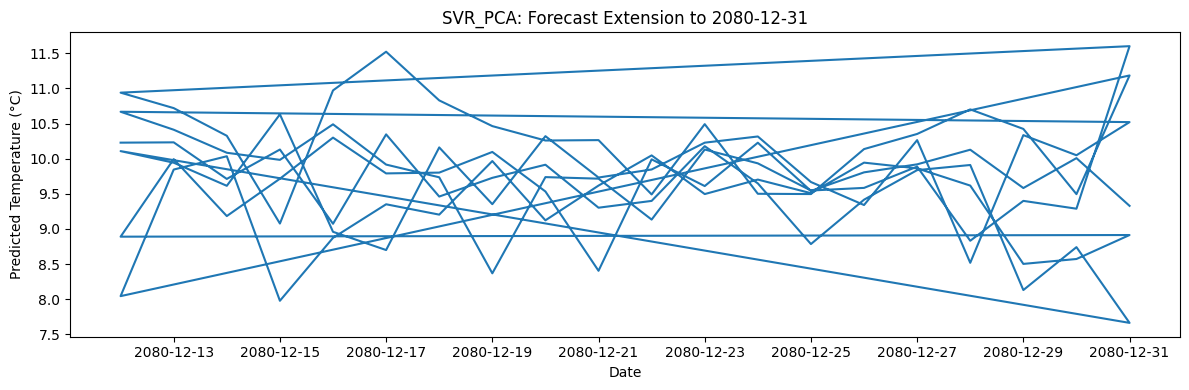

In [11]:
# =========================
# Model 5: PCA + SVR
# =========================

svr_pca_sample_n = min(30000, len(X_train))
X_train_svr_pca = X_train.sample(n=svr_pca_sample_n, random_state=RANDOM_STATE)
y_train_svr_pca = y_train.loc[X_train_svr_pca.index]

svr_pca_model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1,
        gamma="scale"
    ))
])

svr_pca_model.fit(X_train_svr_pca, y_train_svr_pca)
svr_pca_pred_obs = svr_pca_model.predict(X_test_obs)

predictions_obs["SVR_PCA"] = svr_pca_pred_obs
results.append(evaluate_model("SVR_PCA", y_test_obs, svr_pca_pred_obs))

print(f"SVR_PCA trained on {len(X_train_svr_pca)} sampled rows")
print(pd.DataFrame([results[-1]]))
plot_predictions(test_dates_obs, y_test_obs, svr_pca_pred_obs, "SVR_PCA")

if len(X_test_future) > 0:
    svr_pca_pred_future = svr_pca_model.predict(X_test_future)
    predictions_future["SVR_PCA"] = svr_pca_pred_future
    plot_future_only(test_dates_future, svr_pca_pred_future, "SVR_PCA")

In [12]:
# =========================
# Results summary table
# =========================

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2
0,SVR,0.659767,0.481275,0.985099
1,XGB,0.686778,0.507231,0.983854
2,LGBM,0.688883,0.510151,0.983755
3,RF,0.701269,0.529178,0.983166
4,SVR_PCA,0.907336,0.655446,0.971818


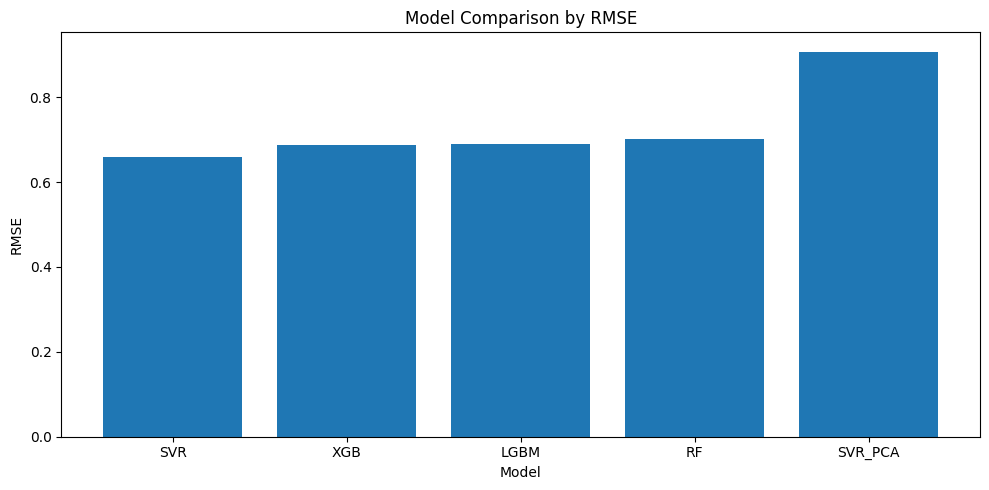

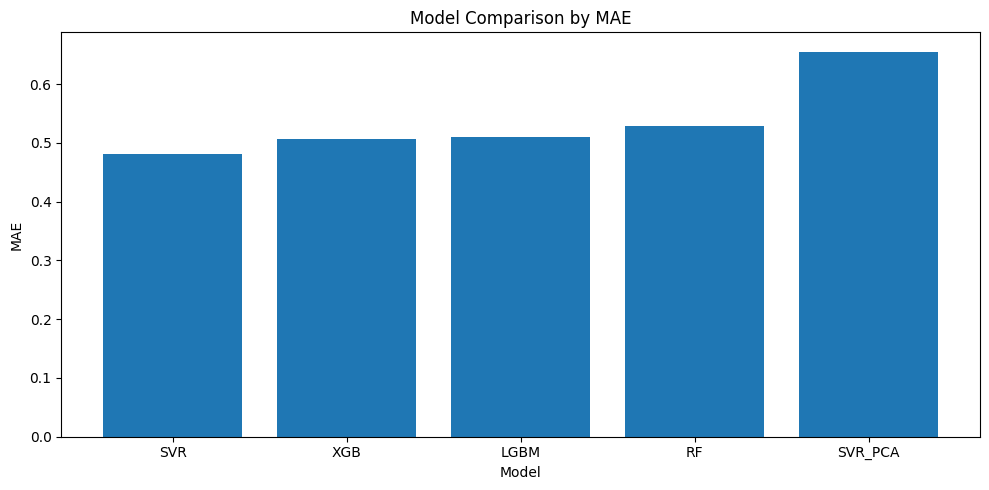

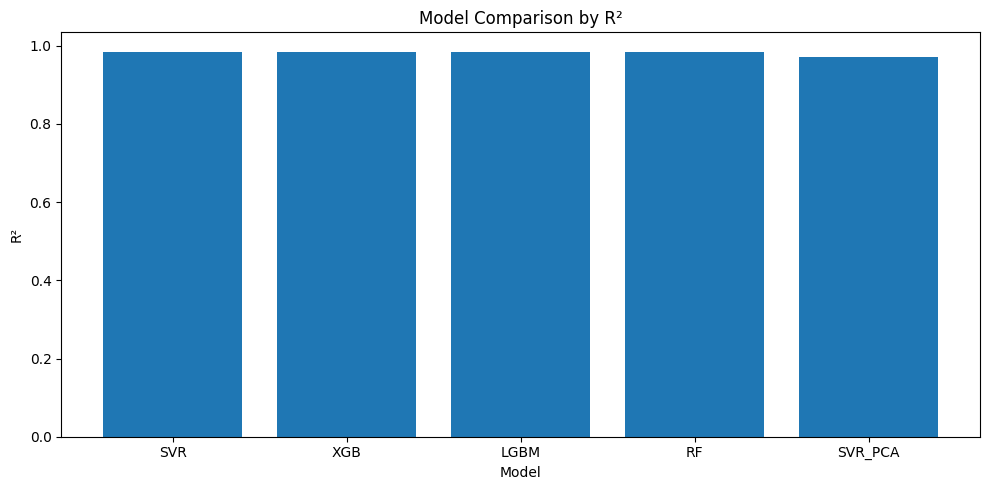

In [13]:
# =========================
# Compare model performance
# =========================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

   Feature    Importance
5   TREFHT  9.409607e-01
0     FLNS  4.048556e-02
6     UBOT  4.547346e-03
1     FSNS  4.519803e-03
4     QBOT  3.181288e-03
7     VBOT  2.881921e-03
9  cos_doy  1.759645e-03
8  sin_doy  1.636541e-03
2    PRECT  2.663027e-05
3     PRSN  5.733011e-07


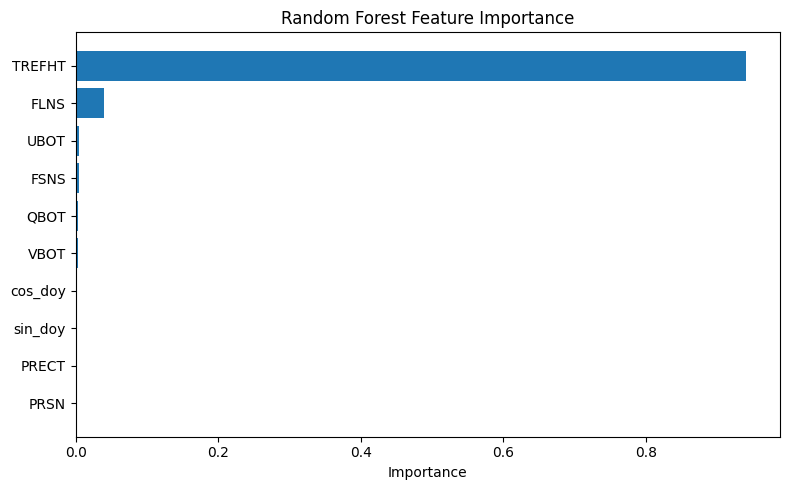

In [14]:
# =========================
# Feature importance from RF
# =========================

rf_fitted = rf_model.named_steps["model"]
importances = rf_fitted.feature_importances_

fi_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(fi_df)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [15]:
# =========================
# Full prediction table for the best model
# =========================

best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

obs_part = pd.DataFrame({
    "Date": test_dates_obs.values,
    "Observed": y_test_obs.values,
    "Predicted": predictions_obs[best_model_name]
})

if best_model_name in predictions_future:
    future_part = pd.DataFrame({
        "Date": test_dates_future.values,
        "Observed": np.nan,
        "Predicted": predictions_future[best_model_name]
    })
    final_pred_df = pd.concat([obs_part, future_part], ignore_index=True)
else:
    final_pred_df = obs_part.copy()

print(final_pred_df.tail(25))
print("Final prediction range:", final_pred_df["Date"].min(), "to", final_pred_df["Date"].max())

Best model: SVR
            Date  Observed  Predicted
67913 2080-12-27       NaN  10.020455
67914 2080-12-28       NaN   9.722978
67915 2080-12-29       NaN  10.082457
67916 2080-12-30       NaN  10.085749
67917 2080-12-31       NaN   9.070891
67918 2080-12-12       NaN  11.571023
67919 2080-12-13       NaN  10.256943
67920 2080-12-14       NaN  10.681134
67921 2080-12-15       NaN  10.521941
67922 2080-12-16       NaN  10.839209
67923 2080-12-17       NaN  10.616685
67924 2080-12-18       NaN  10.181925
67925 2080-12-19       NaN  10.187888
67926 2080-12-20       NaN  10.175858
67927 2080-12-21       NaN  11.508283
67928 2080-12-22       NaN  10.105914
67929 2080-12-23       NaN  10.272022
67930 2080-12-24       NaN  10.665801
67931 2080-12-25       NaN  10.275071
67932 2080-12-26       NaN  10.412497
67933 2080-12-27       NaN  10.253913
67934 2080-12-28       NaN  10.427653
67935 2080-12-29       NaN   9.981979
67936 2080-12-30       NaN  10.172288
67937 2080-12-31       NaN   9.715

In [16]:
final_pred_df.to_csv("best_model_prediction_to_2080_12_31.csv", index=False)
print("Saved: best_model_prediction_to_2080_12_31.csv")

Saved: best_model_prediction_to_2080_12_31.csv


# Conclusion

This notebook evaluated five supervised learning models for predicting daily maximum temperature (`TREFMXAV_U`) in Manchester using CESM-LENS climate predictors.

## Models compared
- XGB
- LGBM
- RF
- SVR
- SVR_PCA

## Evaluation metrics
- RMSE
- MAE
- R²
